In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/029_orsay/results/000.quantification/results/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(34183, 34)


,P9T001,P9T002,P9T003,P9T004,P9T005,P9T006,P9T007,P9T008,P9T009,P9T010,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
ENSMUSG00000000001.5,52.590418,61.495779,53.125823,54.347540,59.766875,64.641351,63.028110,78.664001,48.280840,61.386105,...,74.259682,60.010067,74.122019,72.451684,73.614975,73.117532,73.077172,59.410303,66.997335,68.390766
ENSMUSG00000000003.16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000000028.16,3.074236,9.866062,6.699898,4.222149,6.381881,9.192726,9.823304,8.294256,3.419973,5.826405,...,9.547606,11.365565,15.090812,8.186715,6.009526,12.076935,13.568877,7.562716,6.118012,7.009227
ENSMUSG00000000031.18,7.029637,96.835916,6.403240,13.898170,18.527473,51.161624,40.580560,154.704777,12.128378,27.415353,...,262.781925,30.497847,127.529069,161.613290,15.283542,117.652670,95.044588,198.745750,17.225057,116.076923
ENSMUSG00000000037.18,1.133755,7.668860,4.315301,1.963341,5.148476,4.656148,11.220167,7.900027,1.838547,5.755551,...,9.842729,3.632729,7.654064,5.558040,6.284097,5.708959,6.948767,4.751469,6.040751,6.452964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000121512.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000121513.1,34.708126,10.686098,15.211993,38.435779,13.310473,17.144693,13.023158,15.430192,36.774702,15.052154,...,15.193976,15.925853,17.458391,24.838381,13.285799,15.710126,18.310002,15.535927,15.220670,23.133453
ENSMUSG00001074846.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00002075770.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
for element in expression.columns:
    print(element)

P9T001
P9T002
P9T003
P9T004
P9T005
P9T006
P9T007
P9T008
P9T009
P9T010
P9T011
P9T012
P9T013
P9T014
P9T015
P9T016
P9T017
P9T018
P9T019
P9T020
P9T021
P9T022
P9T023
P9T024
P9T025
P9T026
P9T027
P9T028
P9T029
P9T030
P9T031
P9T032
P9T033
P9T034


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(15735, 34)
(2586, 34)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.21685263 0.13398804]


1 black
2 black
3 black
4 black
5 black
6 black
7 black
8 black
9 black
10 gold
11 gold
12 gold
13 gold
14 gold
15 gold
16 gold
17 gold
18 gold
19 tab:red
20 tab:red
21 tab:red
22 tab:red
23 tab:red
24 tab:red
25 tab:red
26 tab:red
27 tab:red
28 tab:red
29 tab:red
30 tab:red
31 skyblue
32 skyblue
33 skyblue
34 skyblue


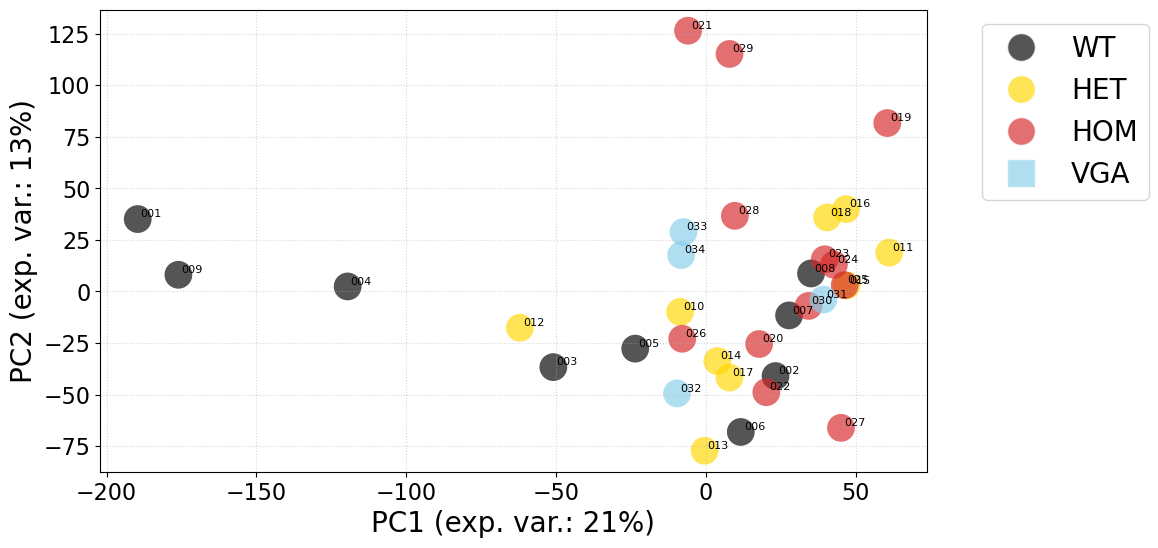

In [10]:
for i in range(len(new)):

    # colors
    rank = int(expression.columns[i].split('T')[1])
    
    if rank < 999:
        the_color = 'skyblue'
    if rank < 31:
        the_color = 'tab:red'
    if rank < 19:
        the_color = 'gold'
    if rank < 10:
        the_color = 'black'
    print(rank, the_color)
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 1
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i].split('T')[1], size=8)

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3)
    
]

matplotlib.pyplot.legend(legend_elements, ['WT', 'HET', 'HOM', 'VGA'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.2613831  0.15142115]


1 black
2 black
3 black
4 black
5 black
6 black
7 black
8 black
9 black
10 gold
11 gold
12 gold
13 gold
14 gold
15 gold
16 gold
17 gold
18 gold
19 tab:red
20 tab:red
21 tab:red
22 tab:red
23 tab:red
24 tab:red
25 tab:red
26 tab:red
27 tab:red
28 tab:red
29 tab:red
30 tab:red
31 skyblue
32 skyblue
33 skyblue
34 skyblue


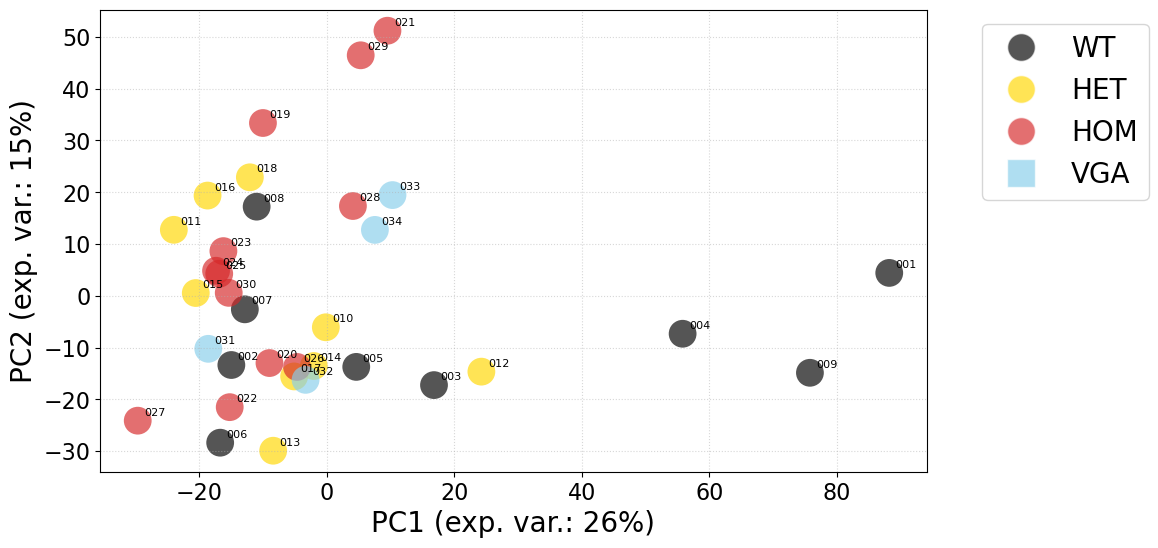

In [12]:
for i in range(len(new)):

    # colors
    rank = int(expression.columns[i].split('T')[1])
    
    if rank < 999:
        the_color = 'skyblue'
    if rank < 31:
        the_color = 'tab:red'
    if rank < 19:
        the_color = 'gold'
    if rank < 10:
        the_color = 'black'
    print(rank, the_color)
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 1
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i].split('T')[1], size=8)

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3)
    
]

matplotlib.pyplot.legend(legend_elements, ['WT', 'HET', 'HOM', 'VGA'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,P9T001,P9T002,P9T003,P9T004,P9T005,P9T006,P9T007,P9T008,P9T009,P9T010,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
ENSMUSG00000000001.5,5.743903,5.965687,5.758245,5.790447,5.925213,6.036533,6.000634,6.315856,5.622955,5.963153,...,6.233805,5.930975,6.231164,6.198724,6.221393,6.211743,6.210957,5.916723,6.087406,6.116672
ENSMUSG00000000003.16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000000028.16,2.026530,3.441757,2.944839,2.384644,2.883989,3.349468,3.436069,3.216339,2.144037,2.771126,...,3.398844,3.628256,4.008165,3.199549,2.809317,3.708953,3.864818,3.098068,2.831474,3.001663
ENSMUSG00000000031.18,3.005335,6.612292,2.888157,3.897063,4.287433,5.704917,5.377837,7.282669,3.714617,4.828599,...,8.043202,4.977181,7.005951,7.345301,4.025343,6.890601,6.585632,7.642021,4.187851,6.871313
ENSMUSG00000000037.18,1.093395,3.115842,2.410152,1.567225,2.620229,2.499820,3.611192,3.153810,1.505153,2.756073,...,3.438656,2.211862,3.113378,2.713265,2.864750,2.746089,2.990731,2.523930,2.815729,2.897814


151
15.007761024957459


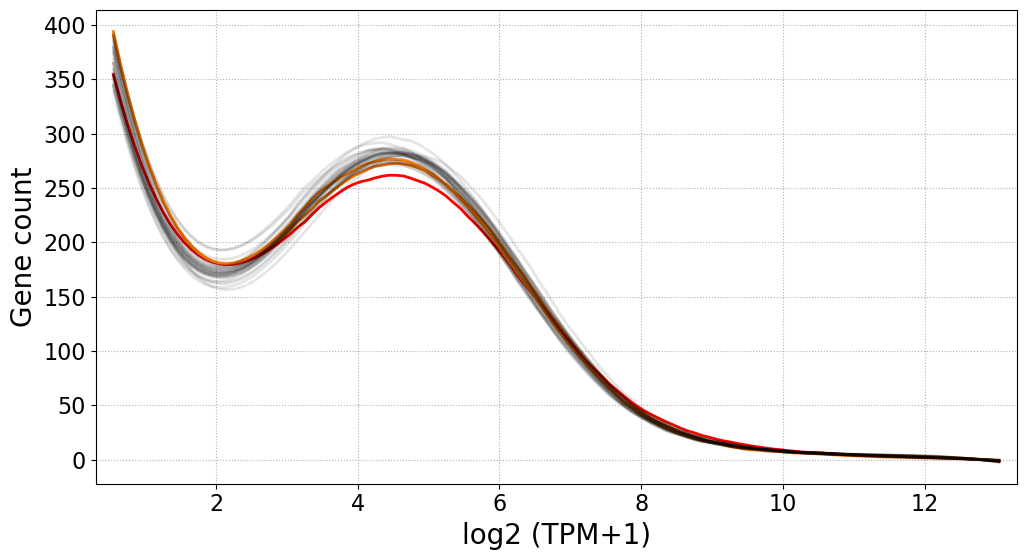

In [15]:
found_max = 15.1
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    sample = working_samples[i]

    the_color = 'black'; the_alpha = 1/10
    if working_samples[i] == 'P9T004':
        the_color = 'red'; the_alpha = 1
    if working_samples[i] == 'P9T001':
        the_color = 'tab:orange'; the_alpha = 1
    if working_samples[i] == 'P9T009':
        the_color = 'tab:orange'; the_alpha = 1
    
    log2TPM = log2_tpm_PO.loc[:, sample]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, '.', alpha=1/100, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=the_alpha, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)